In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000328_08_03_180.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000223_09_02_146.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000229_03_04_202.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000103_01_01_104.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000103_12_01_075.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000143_04_02_153.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/002276_05_03_078.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000020_03_01_166.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000054_03_01_025.png
/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/Test cases/000230_04_01_242.png


In [5]:
%config Completer.use_jedi = False
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import seaborn as sns
import cv2
import random
import os
import imageio
import plotly.graph_objects as go
import plotly.express as px
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, RepeatedStratifiedKFold
from imblearn.over_sampling import SMOTE

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization
from keras.applications import resnet
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB1, EfficientNetB2, EfficientNetB3, EfficientNetB4, EfficientNetB5, EfficientNetB6, EfficientNetB7
from keras.applications.resnet import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img


In [6]:
directory = r'/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset'

categories = ['Bengin cases', 'Malignant cases', 'Normal cases']

Bengin cases - Bengin case (97).jpg
Malignant cases - Malignant case (79).jpg
Normal cases - Normal case (246).jpg


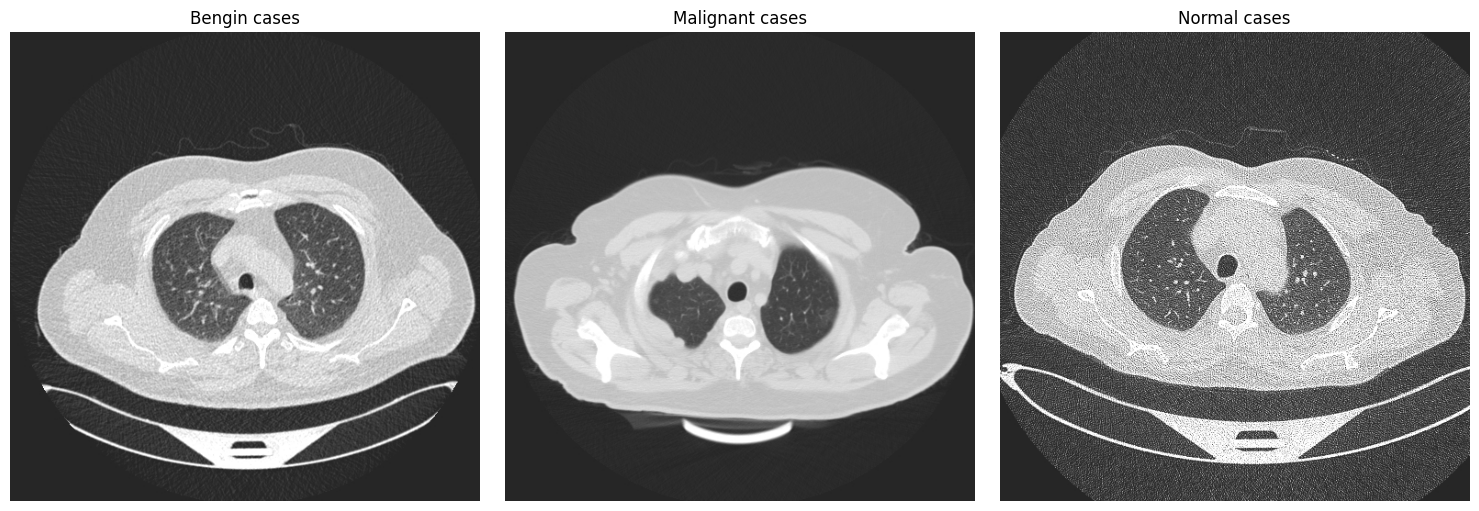

In [7]:
fig, axes = plt.subplots(1, len(categories), figsize=(15, 5))

for i, category in enumerate(categories):
    path = os.path.join(directory, category)
    # Loop files but break after the first one to show just one sample
    for file in os.listdir(path):
        filepath = os.path.join(path, file)
        print(category, '-', file)

        # Baca image asli (BGR) dan konversi ke RGB
        img = cv2.imread(filepath)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Tampilkan di subplot yang sesuai
        axes[i].imshow(img)
        axes[i].set_title(f'{category}')
        axes[i].axis('off')
        break

plt.tight_layout()
plt.show()

In [8]:
size_data = {}
for i in categories:
    path = os.path.join(directory, i)
    class_num = categories.index(i)
    temp_dict = {}
    for file in os.listdir(path):
        filepath = os.path.join(path, file)
        height, width, channels = imageio.imread(filepath).shape
        if str(height) + ' x ' + str(width) in temp_dict:
            temp_dict[str(height) + ' x ' + str(width)] += 1
        else:
            temp_dict[str(height) + ' x ' + str(width)] = 1

    size_data[i] = temp_dict

size_data

/tmp/ipykernel_55/73549651.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  height, width, channels = imageio.imread(filepath).shape


{'Bengin cases': {'512 x 512': 120},
 'Malignant cases': {'512 x 512': 501,
  '512 x 623': 31,
  '512 x 801': 28,
  '404 x 511': 1},
 'Normal cases': {'512 x 512': 415, '331 x 506': 1}}

In [9]:
import os, cv2, random
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Inisialisasi
data = []
img_size = 224 # WAJIB 224 untuk MobileNetV2

# Pastikan variabel 'categories' dan 'directory' sudah didefinisikan sebelumnya
for i in categories:
    path = os.path.join(directory, i)
    class_num = categories.index(i)

    for file in os.listdir(path):
        filepath = os.path.join(path, file)
        
        img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (img_size, img_size))
        # Konversi ke RGB karena MobileNetV2 mengharapkan 3 channel
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        data.append([img, class_num])

# Shuffle untuk memastikan variasi data saat splitting
random.shuffle(data)

# Memisahkan fitur (X) dan label (y)
X, y = zip(*data)
X = np.array(X, dtype=np.float32)
y = np.array(y)

print('--- Data Loaded ---')
print('Total X shape:', X.shape)
print('Label distribution:', Counter(y))

--- Data Loaded ---
Total X shape: (1097, 224, 224, 3)
Label distribution: Counter({np.int64(1): 561, np.int64(2): 416, np.int64(0): 120})


In [10]:
# 1. SPLIT DATA → 70% TRAIN, 15% VALID, 15% TEST
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=10, 
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=10, 
    stratify=y_temp
)

# 2. PREPROCESS (Scaling pixel ke range yang sesuai MobileNetV2)
# X_train = preprocess_input(X_train)
# X_valid = preprocess_input(X_valid)
# X_test  = preprocess_input(X_test)

# 3. CLASS WEIGHT (Mencegah imbalance pada training)
counter = Counter(y_train)
total = len(y_train)
num_classes = len(categories)

class_weights = {i: total / (num_classes * counter[i]) for i in counter}

# 4. ONE HOT ENCODING
y_train = to_categorical(y_train, num_classes=num_classes)
y_valid = to_categorical(y_valid, num_classes=num_classes)
y_test  = to_categorical(y_test,  num_classes=num_classes)

print("--- Preprocessing Complete ---")
print("Class weights:", class_weights)
print("Train shape :", X_train.shape, y_train.shape)
print("Valid shape :", X_valid.shape, y_valid.shape)
print("Test  shape :", X_test.shape,  y_test.shape)

--- Preprocessing Complete ---
Class weights: {np.int64(2): 0.8785796105383734, np.int64(1): 0.6522108843537415, np.int64(0): 3.0436507936507935}
Train shape : (767, 224, 224, 3) (767, 3)
Valid shape : (165, 224, 224, 3) (165, 3)
Test  shape : (165, 224, 224, 3) (165, 3)


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Konfigurasi Augmentasi
# Catatan: Kita hanya mengaugmentasi data TRAIN. 
# Data VALIDATION dan TEST tidak boleh diaugmentasi (hanya di-preprocess).
train_datagen = ImageDataGenerator(
    rotation_range=30,      # Rotasi hingga 30 derajat
    width_shift_range=0.2,  # Pergeseran lebar 20%
    height_shift_range=0.2, # Pergeseran tinggi 20%
    brightness_range=[0.8, 1.2], # Kecerahan antara 80% - 120%
    zoom_range=0.2,         # Zoom in/out 20%
    horizontal_flip=True,   # Flip horizontal
    fill_mode='nearest'     # Mengisi pixel kosong setelah pergeseran/rotasi
)

# Generator untuk data training
# Kita gunakan flow() karena data sudah dalam bentuk array (X_train, y_train)
train_generator = train_datagen.flow(
    X_train, 
    y_train, 
    batch_size=32,
    shuffle=True
)

# Untuk validasi, kita tidak pakai augmentasi (cukup generator standar agar konsisten)
val_datagen = ImageDataGenerator()
val_generator = val_datagen.flow(
    X_valid, 
    y_valid, 
    batch_size=32,
    shuffle=False
)

print("Augmentasi berhasil dikonfigurasi.")
print(f"Batch size: 32")

Augmentasi berhasil dikonfigurasi.
Batch size: 32


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, 
                                      GlobalAveragePooling2D, Reshape, 
                                      Multiply, Input, Layer)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# ─────────────────────────────────────────────
# 2. Custom Channel Attention Module
# ─────────────────────────────────────────────
class ChannelAttention(Layer):
    def __init__(self, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap    = GlobalAveragePooling2D()
        self.dense1 = Dense(max(1, channels // self.ratio), activation='relu')
        self.dense2 = Dense(channels, activation='sigmoid')
        self.reshape = Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, x):
        attn = self.gap(x)
        attn = self.dense1(attn)
        attn = self.dense2(attn)
        attn = self.reshape(attn)
        return Multiply()([x, attn])

    def get_config(self):
        config = super().get_config()
        config.update({'ratio': self.ratio})
        return config


# ─────────────────────────────────────────────
# 3. Bangun CNN + Attention
# ─────────────────────────────────────────────
num_classes = y_train.shape[1]

def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D((2, 2))(x)

    x = Flatten()(x)
    features = Dense(16, activation='relu', name='feature_layer')(x)
    output = Dense(num_classes, activation='softmax', name='softmax_output')(features)

    return Model(inputs, output, name='CNN_Attention')

model2 = build_model(X_train.shape[1:], num_classes)
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model2.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')],
    verbose=1
)


# ─────────────────────────────────────────────
# 5. Ekstrak Fitur dari 'feature_layer'
# ─────────────────────────────────────────────
extractor = Model(
    inputs=model2.input,
    outputs=model2.get_layer('feature_layer').output
)

# Pakai data asli (tanpa augmentasi) untuk ekstraksi fitur
X_train_feat = extractor.predict(X_train, verbose=0)
X_val_feat   = extractor.predict(X_valid, verbose=0)
X_test_feat  = extractor.predict(X_test,  verbose=0)

print(f"\nShape fitur train : {X_train_feat.shape}")
print(f"Shape fitur val   : {X_val_feat.shape}")
print(f"Shape fitur test  : {X_test_feat.shape}")


# ─────────────────────────────────────────────
# 6. Konversi Label One-Hot → Integer untuk SVM
# ─────────────────────────────────────────────
y_train_int = np.argmax(y_train, axis=1)
y_valid_int = np.argmax(y_valid, axis=1)
y_test_int  = np.argmax(y_test,  axis=1)


# ─────────────────────────────────────────────
# 7. Normalisasi Fitur
# ─────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled   = scaler.transform(X_val_feat)
X_test_scaled  = scaler.transform(X_test_feat)

# Gabungkan train + val untuk melatih SVM
X_svm_train = np.vstack([X_train_scaled, X_val_scaled])
y_svm_train = np.concatenate([y_train_int, y_valid_int])


# ─────────────────────────────────────────────
# 8. Latih SVM
# ─────────────────────────────────────────────
svm_clf1 = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)
svm_clf1.fit(X_svm_train, y_svm_train)
print("\nSVM selesai dilatih.")


# ─────────────────────────────────────────────
# 9. Evaluasi pada Test Set
# ─────────────────────────────────────────────
y_pred = svm_clf1.predict(X_test_scaled)

print("\n=== Hasil CNN + Attention + SVM ===")
print(f"Accuracy : {accuracy_score(y_test_int, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_int, y_pred))


2026-04-07 14:58:47.795992: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.5278 - loss: 83.8807 - val_accuracy: 0.8242 - val_loss: 0.4159
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.8661 - loss: 0.3257 - val_accuracy: 0.8970 - val_loss: 0.2190
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.9343 - loss: 0.1620 - val_accuracy: 0.9455 - val_loss: 0.1459
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.9320 - loss: 0.1289 - val_accuracy: 0.9212 - val_loss: 0.1005
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.9553 - loss: 0.1087 - val_accuracy: 0.9455 - val_loss: 0.1112
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.9823 - loss: 0.0513 - val_accuracy: 0.9758 - val_loss: 0.1079
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.9836 - loss: 0.0335 - val_accuracy: 0.9939 - val_loss: 0.0434
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.9962 - loss: 0.0171 - val_accuracy: 0.9939 - val_loss

In [13]:
from sklearn.metrics import (accuracy_score, classification_report, 
                              confusion_matrix, roc_auc_score)
from sklearn.preprocessing import label_binarize
import numpy as np

# ─────────────────────────────────────────────
# Persiapan
# ─────────────────────────────────────────────
y_pred       = svm_clf1.predict(X_test_scaled)
y_pred_proba = svm_clf1.predict_proba(X_test_scaled)
y_test_bin   = label_binarize(y_test_int, classes=[0, 1, 2])
class_names  = ['Class 0', 'Class 1', 'Class 2']  # Ganti sesuai labelmu

# ─────────────────────────────────────────────
# Hitung Metrik per Class dari Confusion Matrix
# ─────────────────────────────────────────────
cm = confusion_matrix(y_test_int, y_pred)

sensitivity_list = []
specificity_list = []
precision_list   = []

for i in range(len(class_names)):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP          # baris i, bukan kolom i
    FP = cm[:, i].sum() - TP          # kolom i, bukan baris i
    TN = cm.sum() - TP - FN - FP

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision   = TP / (TP + FP) if (TP + FP) > 0 else 0.0

    sensitivity_list.append(sensitivity)
    specificity_list.append(specificity)
    precision_list.append(precision)

# ─────────────────────────────────────────────
# AUC per Class + Macro + Micro
# ─────────────────────────────────────────────
auc_per_class = roc_auc_score(y_test_bin, y_pred_proba, 
                               average=None, multi_class='ovr')
auc_macro     = roc_auc_score(y_test_bin, y_pred_proba, 
                               average='macro', multi_class='ovr')
auc_micro     = roc_auc_score(y_test_bin, y_pred_proba, 
                               average='micro', multi_class='ovr')

# Overall Accuracy
accuracy = accuracy_score(y_test_int, y_pred)

# ─────────────────────────────────────────────
# Tampilkan Hasil
# ─────────────────────────────────────────────
header = f"{'Metric':<20}" + "".join([f"{c:>12}" for c in class_names]) + f"{'Mean':>12}"
print("=" * (20 + 12 * (len(class_names) + 1)))
print("  CNN + CBAM + SVM — Test Set Metrics")
print("=" * (20 + 12 * (len(class_names) + 1)))
print(header)
print("-" * (20 + 12 * (len(class_names) + 1)))

# Sensitivity
row = f"{'Sensitivity':<20}" + "".join([f"{v:>12.4f}" for v in sensitivity_list])
row += f"{np.mean(sensitivity_list):>12.4f}"
print(row)

# Specificity
row = f"{'Specificity':<20}" + "".join([f"{v:>12.4f}" for v in specificity_list])
row += f"{np.mean(specificity_list):>12.4f}"
print(row)

# Precision
row = f"{'Precision':<20}" + "".join([f"{v:>12.4f}" for v in precision_list])
row += f"{np.mean(precision_list):>12.4f}"
print(row)

# AUC per class
row = f"{'AUC':<20}" + "".join([f"{v:>12.4f}" for v in auc_per_class])
row += f"{np.mean(auc_per_class):>12.4f}"
print(row)

print("-" * (20 + 12 * (len(class_names) + 1)))

# Overall metrics
print(f"{'Accuracy':<20}{accuracy:>12.4f}")
print(f"{'AUC Macro':<20}{auc_macro:>12.4f}")
print(f"{'AUC Micro':<20}{auc_micro:>12.4f}")
print("=" * (20 + 12 * (len(class_names) + 1)))

  CNN + CBAM + SVM — Test Set Metrics
Metric                   Class 0     Class 1     Class 2        Mean
--------------------------------------------------------------------
Sensitivity               0.9444      1.0000      1.0000      0.9815
Specificity               1.0000      1.0000      0.9902      0.9967
Precision                 1.0000      1.0000      0.9844      0.9948
AUC                       0.9917      1.0000      0.9970      0.9962
--------------------------------------------------------------------
Accuracy                  0.9939
AUC Macro                 0.9962
AUC Micro                 0.9988


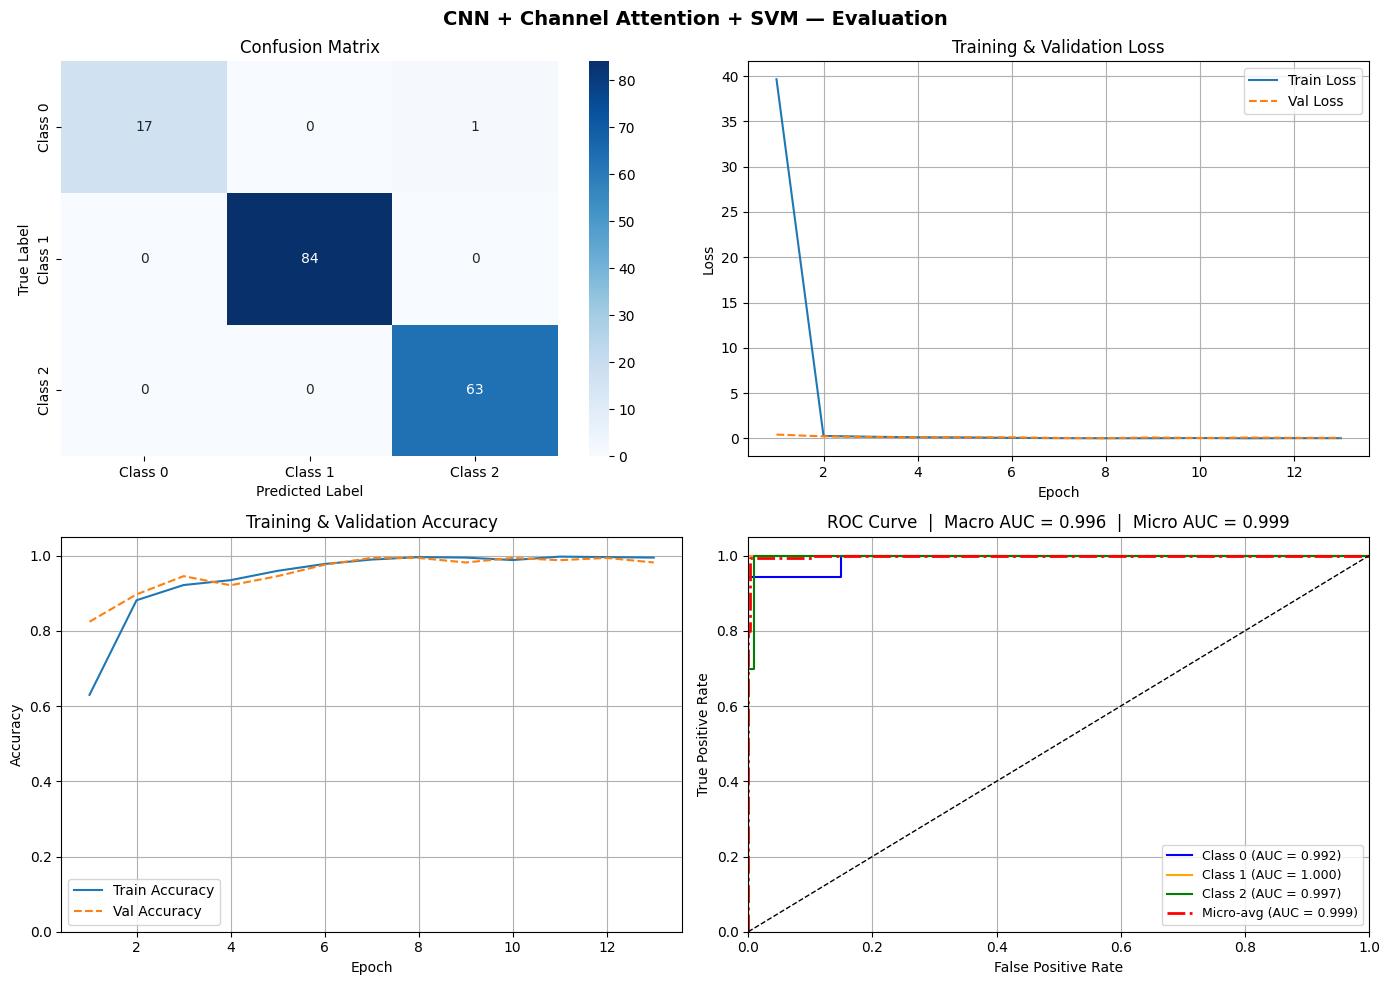

Macro AUC : 0.9962
Micro AUC : 0.9988


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

# ─────────────────────────────────────────────
# Persiapan Data
# ─────────────────────────────────────────────
y_pred       = svm_clf1.predict(X_test_scaled)
y_pred_proba = svm_clf1.predict_proba(X_test_scaled)
class_names  = ['Class 0', 'Class 1', 'Class 2']  # Ganti sesuai labelmu

y_test_bin = label_binarize(y_test_int, classes=[0, 1, 2])

# AUC
auc_macro = roc_auc_score(y_test_bin, y_pred_proba, average='macro', multi_class='ovr')
auc_micro = roc_auc_score(y_test_bin, y_pred_proba, average='micro', multi_class='ovr')

# ROC per class
fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
for i in range(3):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc_micro_curve      = auc(fpr_micro, tpr_micro)

epochs_range = range(1, len(history.history['loss']) + 1)


# ─────────────────────────────────────────────
# Figure
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CNN + Channel Attention + SVM — Evaluation', fontsize=14, fontweight='bold')


# ── Plot 1: Confusion Matrix ──
cm = confusion_matrix(y_test_int, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')


# ── Plot 2: Loss ──
axes[0, 1].plot(epochs_range, history.history['loss'],     label='Train Loss')
axes[0, 1].plot(epochs_range, history.history['val_loss'], label='Val Loss', linestyle='--')
axes[0, 1].set_title('Training & Validation Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)


# ── Plot 3: Accuracy ──
axes[1, 0].plot(epochs_range, history.history['accuracy'],     label='Train Accuracy')
axes[1, 0].plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy', linestyle='--')
axes[1, 0].set_title('Training & Validation Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim([0, 1.05])
axes[1, 0].legend()
axes[1, 0].grid(True)


# ── Plot 4: ROC Curve ──
colors = ['blue', 'orange', 'green']
for i in range(3):
    axes[1, 1].plot(fpr_dict[i], tpr_dict[i], color=colors[i], linewidth=1.5,
                    label=f'{class_names[i]} (AUC = {roc_auc_dict[i]:.3f})')

axes[1, 1].plot(fpr_micro, tpr_micro, color='red', linewidth=2, linestyle='-.',
                label=f'Micro-avg (AUC = {roc_auc_micro_curve:.3f})')
axes[1, 1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1, 1].set_title(f'ROC Curve  |  Macro AUC = {auc_macro:.3f}  |  Micro AUC = {auc_micro:.3f}')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_xlim([0, 1])
axes[1, 1].set_ylim([0, 1.05])
axes[1, 1].legend(loc='lower right', fontsize=9)
axes[1, 1].grid(True)


plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Macro AUC : {auc_macro:.4f}")
print(f"Micro AUC : {auc_micro:.4f}")

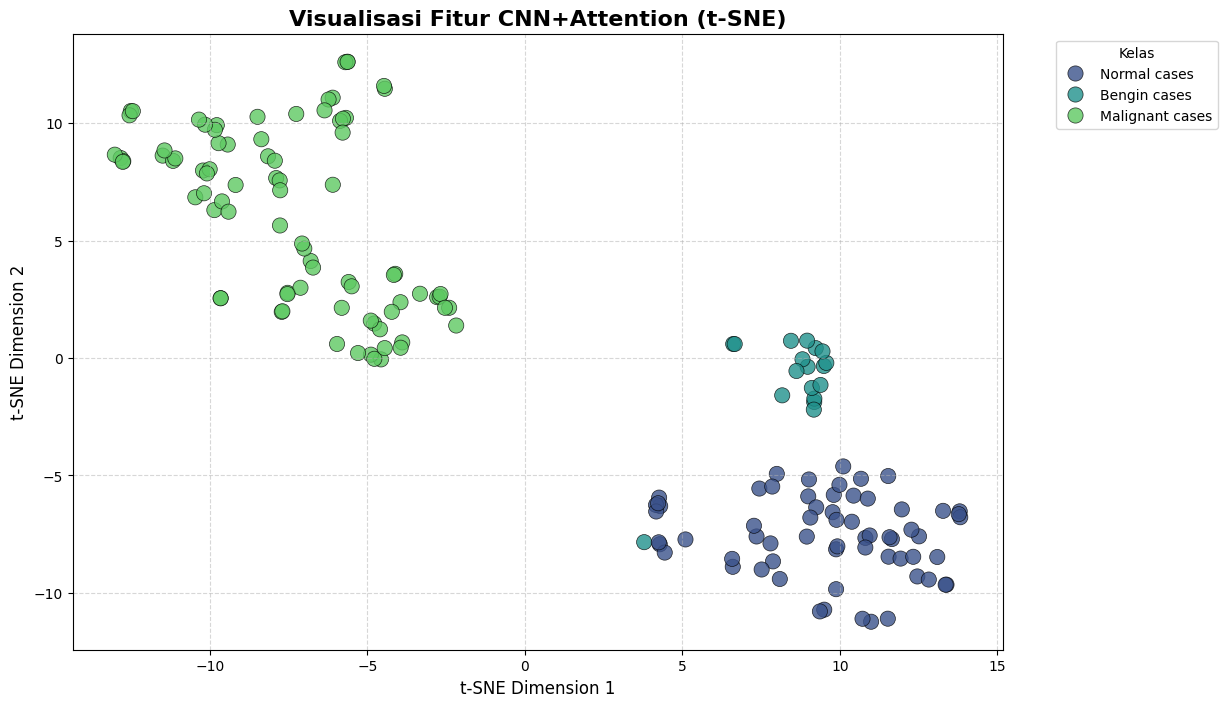

Grafik t-SNE berhasil disimpan sebagai 'visualisasi_tsne_hasil.png'


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import pandas as pd

# --- Proses t-SNE ---
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_test_scaled)

# --- Plotting ---
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=[categories[i] for i in y_test_int],
    palette='viridis',
    s=120, alpha=0.8, edgecolors='black', linewidth=0.5
)

plt.title('Visualisasi Fitur CNN+Attention (t-SNE)', fontsize=16, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(title='Kelas', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# --- SIMPAN GAMBAR ---
# bbox_inches='tight' agar legenda tidak terpotong
plt.savefig('visualisasi_tsne_hasil.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafik t-SNE berhasil disimpan sebagai 'visualisasi_tsne_hasil.png'")

In [16]:
import joblib
import os

# Buat folder khusus untuk menyimpan model
os.makedirs('saved_models', exist_ok=True)

# 1. Simpan Model CNN (H5 atau SavedModel format)
# Kita simpan model extractor-nya saja karena itu yang paling penting
extractor.save('saved_models/cnn_attention_extractor.h5')

# 2. Simpan SVM Classifier
joblib.dump(svm_clf1, 'saved_models/svm_classifier.pkl')

# 3. Simpan Scaler (SANGAT PENTING: agar data baru di-scale dengan cara yang sama)
joblib.dump(scaler, 'saved_models/feature_scaler.pkl')

print("Semua komponen model berhasil disimpan di folder 'saved_models'!")

Semua komponen model berhasil disimpan di folder 'saved_models'!


Building CNN + Attention Model


Model: "CNN_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_4             │ (None, 224, 224, 64)   │         1,096 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_5             │ (None, 112, 112, 64)   │         1,096 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 16)             │     3,211,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_output (Dense)          │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,252,243 (12.41 MB)

 Trainable params: 3,252,243 (12.41 MB)

...

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1775577367.642468      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775577367.642497      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


[PTQ Setup] ✓ Feature extractor quantized

PIPELINE A: ORIGINAL MODEL (float32)
Model size: 38180.6 KB
Feature extraction time: 27.742 s
Feature shape: (165, 16)
SVM training time: 0.028 s
Inference time: 0.0012 s
Test accuracy: 0.9939

Classification Report (Original):
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00        84
           2       0.98      1.00      0.99        63

    accuracy                           0.99       165
   macro avg       0.99      0.98      0.99       165
weighted avg       0.99      0.99      0.99       165


PIPELINE B: QUANTIZED MODEL (INT8 TFLite)
Model size: 3193.2 KB
Compression: 12.0x smaller
Feature extraction time: 37.152 s
Feature shape: (165, 16)
SVM training time: 0.028 s
Inference time: 0.0012 s
Test accuracy: 0.9939

Classification Report (PTQ):
              precision    recall  f1-score   support

           0       1.00      0.94     

/tmp/ipykernel_55/2216335531.py:394: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/2216335531.py:395: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('ptq_comparison.png', dpi=150, bbox_inches='tight')



✓ Visualization saved: ptq_comparison.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


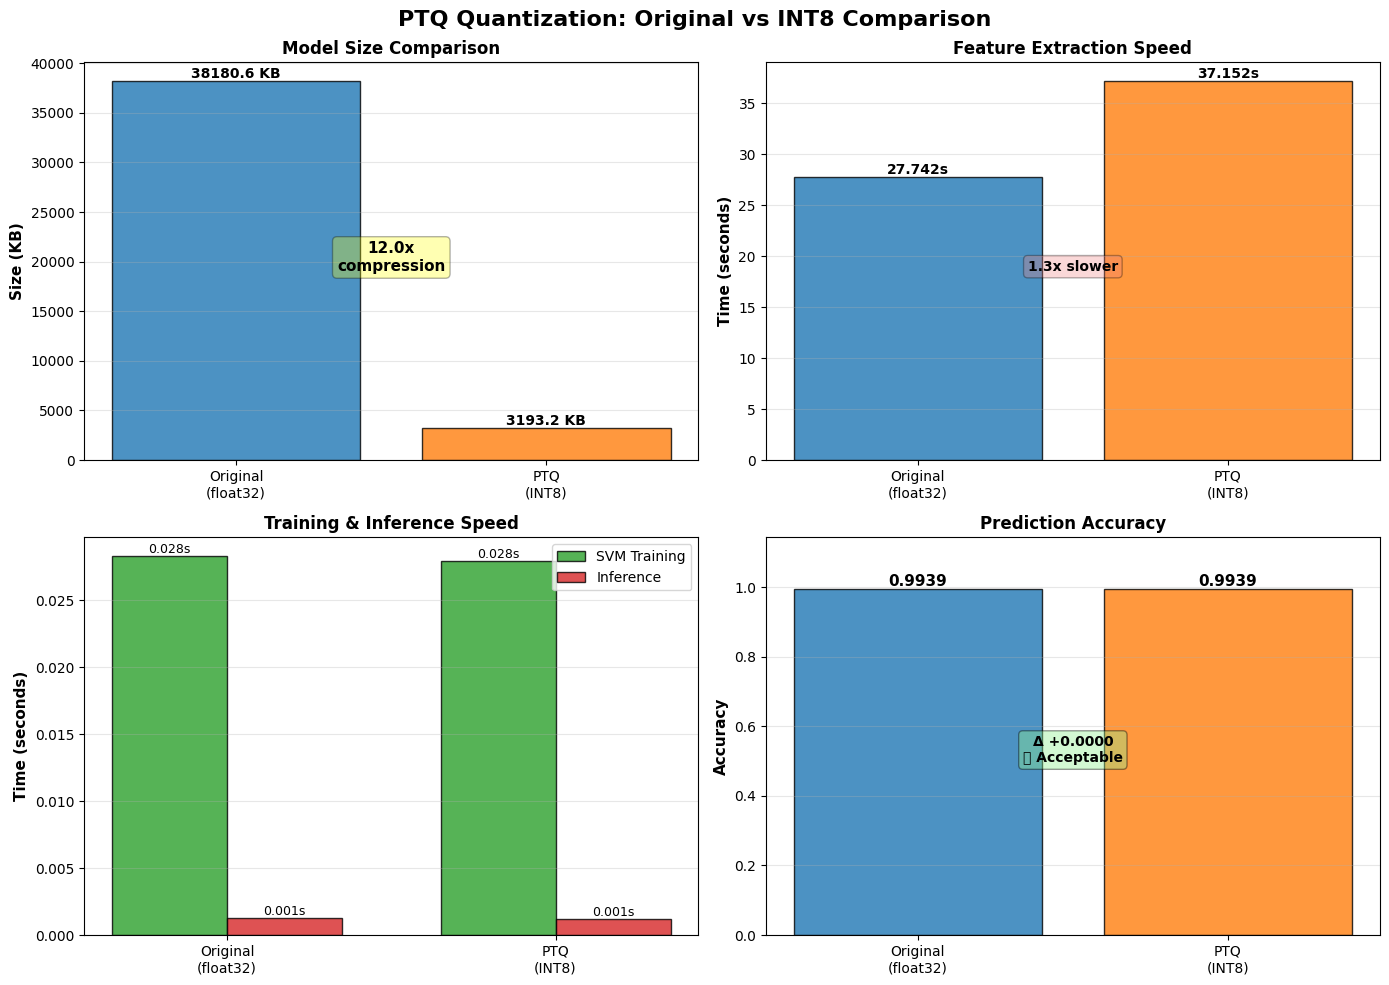


FINAL SUMMARY

Metric                    Original (float32)   PTQ (INT8)          
---------------------------------------------------------------------------
Model Size                        38180.6 KB             3193.2 KB
Compression               1.0x                            12.0x
Feature Extraction                 27.742 s             37.152 s
SVM Training                        0.028 s              0.028 s
Inference                          0.0012 s             0.0012 s
Accuracy                           0.9939             0.9939
Δ Accuracy                -                            +0.0000

📊 Key Findings:
  • Model size reduced by 12.0x (38180.6 KB → 3193.2 KB)
  • Feature extraction slower (0.75x)
  • Accuracy impact: +0.0000 (Negligible change ✅)


In [22]:
"""
Complete CNN + Attention + SVM Pipeline with PTQ Quantization
Trains original float32 model, applies INT8 quantization, compares both.
"""

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, 
                                      GlobalAveragePooling2D, Reshape, 
                                      Multiply, Input, Layer)
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import os
import time
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score


# ═══════════════════════════════════════════════════════════════════════════
# PART A: MODEL DEFINITION & TRAINING
# ═══════════════════════════════════════════════════════════════════════════

class ChannelAttention(Layer):
    """Custom Channel Attention Module"""
    def __init__(self, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap    = GlobalAveragePooling2D()
        self.dense1 = Dense(max(1, channels // self.ratio), activation='relu')
        self.dense2 = Dense(channels, activation='sigmoid')
        self.reshape = Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, x):
        attn = self.gap(x)
        attn = self.dense1(attn)
        attn = self.dense2(attn)
        attn = self.reshape(attn)
        return Multiply()([x, attn])

    def get_config(self):
        config = super().get_config()
        config.update({'ratio': self.ratio})
        return config


def build_cnn_attention_model(input_shape, num_classes):
    """Build CNN + Attention model"""
    inputs = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D((2, 2))(x)

    x = Flatten()(x)
    features = Dense(16, activation='relu', name='feature_layer')(x)
    output = Dense(num_classes, activation='softmax', name='softmax_output')(features)

    return Model(inputs, output, name='CNN_Attention')


# ═══════════════════════════════════════════════════════════════════════════
# PART B: PTQ QUANTIZATION & FEATURE EXTRACTION
# ═══════════════════════════════════════════════════════════════════════════

def setup_ptq_quantization(model, X_train):
    """
    Quantize model to INT8 TFLite format.
    Returns paths to quantized models.
    """
    # Save original
    model.save("cnn_attention_model.keras")
    print("[PTQ Setup] ✓ Original model saved")
    
    # Representative dataset for INT8 calibration
    def representative_dataset():
        num_samples = min(200, len(X_train))
        for i in range(num_samples):
            sample = X_train[i:i+1].astype(np.float32)
            yield [sample]
    
    # Quantize main model
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.float32
    converter.inference_output_type = tf.float32
    
    tflite_model = converter.convert()
    main_model_path = "cnn_attention_ptq_int8.tflite"
    with open(main_model_path, "wb") as f:
        f.write(tflite_model)
    print(f"[PTQ Setup] ✓ Main model quantized → {main_model_path}")
    
    # Quantize feature extractor
    extractor = Model(
        inputs=model.input,
        outputs=model.get_layer('feature_layer').output
    )
    
    converter_ext = tf.lite.TFLiteConverter.from_keras_model(extractor)
    converter_ext.optimizations = [tf.lite.Optimize.DEFAULT]
    converter_ext.representative_dataset = representative_dataset
    converter_ext.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter_ext.inference_input_type = tf.float32
    converter_ext.inference_output_type = tf.float32
    
    tflite_extractor = converter_ext.convert()
    print("[PTQ Setup] ✓ Feature extractor quantized")
    
    # Load interpreter
    interp_ext = tf.lite.Interpreter(model_content=tflite_extractor)
    interp_ext.allocate_tensors()
    
    return main_model_path, interp_ext


def extract_features_tflite(interpreter, X):
    """Extract features from INT8 quantized TFLite model."""
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    features = []
    for sample in X:
        input_tensor = np.expand_dims(sample, axis=0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], input_tensor)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])[0].copy()
        features.append(output)
    
    return np.array(features)


# ═══════════════════════════════════════════════════════════════════════════
# PART C: PIPELINE EXECUTION & COMPARISON
# ═══════════════════════════════════════════════════════════════════════════

def run_complete_pipeline(model, X_train, X_valid, X_test, 
                         y_train, y_valid, y_test):
    """
    Execute complete pipeline:
    1. Train original model (already done externally)
    2. Setup PTQ quantization
    3. Run feature extraction on both pipelines
    4. Train SVM on both
    5. Compare results
    """
    
    # Convert labels to integers
    y_train_int = np.argmax(y_train, axis=1)
    y_valid_int = np.argmax(y_valid, axis=1)
    y_test_int = np.argmax(y_test, axis=1)
    
    # Setup PTQ
    tflite_path, interp_ext = setup_ptq_quantization(model, X_train)
    
    # ─────────────────────────────────────────────────────────────────────
    print("\n" + "="*70)
    print("PIPELINE A: ORIGINAL MODEL (float32)")
    print("="*70)
    
    size_orig_kb = os.path.getsize("cnn_attention_model.keras") / 1024
    print(f"Model size: {size_orig_kb:.1f} KB")
    
    # Feature extraction
    extractor_orig = Model(
        inputs=model.input,
        outputs=model.get_layer('feature_layer').output
    )
    
    t0 = time.time()
    X_train_feat_orig = extractor_orig.predict(X_train, verbose=0)
    X_val_feat_orig = extractor_orig.predict(X_valid, verbose=0)
    X_test_feat_orig = extractor_orig.predict(X_test, verbose=0)
    t_feat_orig = time.time() - t0
    
    print(f"Feature extraction time: {t_feat_orig:.3f} s")
    print(f"Feature shape: {X_test_feat_orig.shape}")
    
    # Normalize
    scaler_orig = StandardScaler()
    X_train_scaled_orig = scaler_orig.fit_transform(X_train_feat_orig)
    X_val_scaled_orig = scaler_orig.transform(X_val_feat_orig)
    X_test_scaled_orig = scaler_orig.transform(X_test_feat_orig)
    
    # Combine train+val
    X_svm_train_orig = np.vstack([X_train_scaled_orig, X_val_scaled_orig])
    y_svm_train_orig = np.concatenate([y_train_int, y_valid_int])
    
    # Train SVM
    t0 = time.time()
    svm_orig = SVC(kernel='rbf', C=1.0, gamma='scale', 
                   probability=True, random_state=42)
    svm_orig.fit(X_svm_train_orig, y_svm_train_orig)
    t_svm_orig = time.time() - t0
    
    print(f"SVM training time: {t_svm_orig:.3f} s")
    
    # Inference
    t0 = time.time()
    y_pred_orig = svm_orig.predict(X_test_scaled_orig)
    t_inf_orig = time.time() - t0
    
    acc_orig = accuracy_score(y_test_int, y_pred_orig)
    print(f"Inference time: {t_inf_orig:.4f} s")
    print(f"Test accuracy: {acc_orig:.4f}")
    print("\nClassification Report (Original):")
    print(classification_report(y_test_int, y_pred_orig, zero_division=0))
    
    # ─────────────────────────────────────────────────────────────────────
    print("\n" + "="*70)
    print("PIPELINE B: QUANTIZED MODEL (INT8 TFLite)")
    print("="*70)
    
    size_ptq_kb = os.path.getsize(tflite_path) / 1024
    compression = size_orig_kb / size_ptq_kb
    print(f"Model size: {size_ptq_kb:.1f} KB")
    print(f"Compression: {compression:.1f}x smaller")
    
    # Feature extraction
    t0 = time.time()
    X_train_feat_ptq = extract_features_tflite(interp_ext, X_train)
    X_val_feat_ptq = extract_features_tflite(interp_ext, X_valid)
    X_test_feat_ptq = extract_features_tflite(interp_ext, X_test)
    t_feat_ptq = time.time() - t0
    
    print(f"Feature extraction time: {t_feat_ptq:.3f} s")
    print(f"Feature shape: {X_test_feat_ptq.shape}")
    
    # Normalize
    scaler_ptq = StandardScaler()
    X_train_scaled_ptq = scaler_ptq.fit_transform(X_train_feat_ptq)
    X_val_scaled_ptq = scaler_ptq.transform(X_val_feat_ptq)
    X_test_scaled_ptq = scaler_ptq.transform(X_test_feat_ptq)
    
    # Combine train+val
    X_svm_train_ptq = np.vstack([X_train_scaled_ptq, X_val_scaled_ptq])
    y_svm_train_ptq = np.concatenate([y_train_int, y_valid_int])
    
    # Train SVM
    t0 = time.time()
    svm_ptq = SVC(kernel='rbf', C=1.0, gamma='scale',
                  probability=True, random_state=42)
    svm_ptq.fit(X_svm_train_ptq, y_svm_train_ptq)
    t_svm_ptq = time.time() - t0
    
    print(f"SVM training time: {t_svm_ptq:.3f} s")
    
    # Inference
    t0 = time.time()
    y_pred_ptq = svm_ptq.predict(X_test_scaled_ptq)
    t_inf_ptq = time.time() - t0
    
    acc_ptq = accuracy_score(y_test_int, y_pred_ptq)
    print(f"Inference time: {t_inf_ptq:.4f} s")
    print(f"Test accuracy: {acc_ptq:.4f}")
    print("\nClassification Report (PTQ):")
    print(classification_report(y_test_int, y_pred_ptq, zero_division=0))
    
    # ─────────────────────────────────────────────────────────────────────
    # Collect metrics
    metrics = {
        'size_kb': [size_orig_kb, size_ptq_kb],
        't_feature': [t_feat_orig, t_feat_ptq],
        't_svm': [t_svm_orig, t_svm_ptq],
        't_infer': [t_inf_orig, t_inf_ptq],
        'accuracy': [acc_orig, acc_ptq],
    }
    
    eval_data = (y_test_int, y_pred_orig, y_pred_ptq)
    
    return metrics, eval_data


# ═══════════════════════════════════════════════════════════════════════════
# PART D: VISUALIZATION & SUMMARY
# ═══════════════════════════════════════════════════════════════════════════

def visualize_comparison(metrics):
    """Create 4-panel matplotlib comparison dashboard."""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('PTQ Quantization: Original vs INT8 Comparison', 
                 fontsize=16, fontweight='bold')
    
    models = ['Original\n(float32)', 'PTQ\n(INT8)']
    colors = ['#1f77b4', '#ff7f0e']
    
    # ─────────────────────────────────────────────────────────────────────
    # Plot 1: Model Size
    # ─────────────────────────────────────────────────────────────────────
    ax = axes[0, 0]
    bars = ax.bar(models, metrics['size_kb'], color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Size (KB)', fontsize=11, fontweight='bold')
    ax.set_title('Model Size Comparison', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    for i, (bar, val) in enumerate(zip(bars, metrics['size_kb'])):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1f} KB', ha='center', va='bottom', 
                fontweight='bold', fontsize=10)
    
    compression = metrics['size_kb'][0] / metrics['size_kb'][1]
    ax.text(0.5, max(metrics['size_kb']) * 0.5,
            f'{compression:.1f}x\ncompression',
            ha='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    
    # ─────────────────────────────────────────────────────────────────────
    # Plot 2: Feature Extraction Time
    # ─────────────────────────────────────────────────────────────────────
    ax = axes[0, 1]
    bars = ax.bar(models, metrics['t_feature'], color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
    ax.set_title('Feature Extraction Speed', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    for bar, val in zip(bars, metrics['t_feature']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}s', ha='center', va='bottom', 
                fontweight='bold', fontsize=10)
    
    speedup = metrics['t_feature'][0] / metrics['t_feature'][1]
    speedup_text = f'{speedup:.1f}x faster' if speedup >= 1 else f'{1/speedup:.1f}x slower'
    ax.text(0.5, max(metrics['t_feature']) * 0.5, speedup_text,
            ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', 
                     facecolor='lightgreen' if speedup >= 1 else 'lightcoral', 
                     alpha=0.3))
    
    # ─────────────────────────────────────────────────────────────────────
    # Plot 3: Training & Inference Time
    # ─────────────────────────────────────────────────────────────────────
    ax = axes[1, 0]
    x = np.arange(len(models))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, metrics['t_svm'], width, label='SVM Training',
                   color='#2ca02c', alpha=0.8, edgecolor='black')
    bars2 = ax.bar(x + width/2, metrics['t_infer'], width, label='Inference',
                   color='#d62728', alpha=0.8, edgecolor='black')
    
    ax.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
    ax.set_title('Training & Inference Speed', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}s', ha='center', va='bottom', fontsize=9)
    
    # ─────────────────────────────────────────────────────────────────────
    # Plot 4: Accuracy
    # ─────────────────────────────────────────────────────────────────────
    ax = axes[1, 1]
    bars = ax.bar(models, metrics['accuracy'], color=colors, alpha=0.8,
                  edgecolor='black')
    ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax.set_title('Prediction Accuracy', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(metrics['accuracy']) * 1.15)
    
    for bar, val in zip(bars, metrics['accuracy']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', 
                fontweight='bold', fontsize=11)
    
    delta_acc = metrics['accuracy'][1] - metrics['accuracy'][0]
    status = '✅ Acceptable' if abs(delta_acc) < 0.02 else '⚠️ Review needed'
    ax.text(0.5, max(metrics['accuracy']) * 0.5,
            f'Δ {delta_acc:+.4f}\n{status}',
            ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', 
                     facecolor='lightgreen' if abs(delta_acc) < 0.02 else 'lightyellow',
                     alpha=0.4))
    
    plt.tight_layout()
    plt.savefig('ptq_comparison.png', dpi=150, bbox_inches='tight')
    print("\n✓ Visualization saved: ptq_comparison.png")
    plt.show()


def print_summary(metrics, eval_data):
    """Print detailed summary table."""
    y_test_int, y_pred_orig, y_pred_ptq = eval_data
    
    print("\n" + "="*75)
    print("FINAL SUMMARY")
    print("="*75)
    print(f"\n{'Metric':<25} {'Original (float32)':<20} {'PTQ (INT8)':<20}")
    print("-"*75)
    print(f"{'Model Size':<25} {metrics['size_kb'][0]:>15.1f} KB    {metrics['size_kb'][1]:>15.1f} KB")
    print(f"{'Compression':<25} {'1.0x':<20} {metrics['size_kb'][0]/metrics['size_kb'][1]:>15.1f}x")
    print(f"{'Feature Extraction':<25} {metrics['t_feature'][0]:>15.3f} s    {metrics['t_feature'][1]:>15.3f} s")
    print(f"{'SVM Training':<25} {metrics['t_svm'][0]:>15.3f} s    {metrics['t_svm'][1]:>15.3f} s")
    print(f"{'Inference':<25} {metrics['t_infer'][0]:>15.4f} s    {metrics['t_infer'][1]:>15.4f} s")
    print(f"{'Accuracy':<25} {metrics['accuracy'][0]:>15.4f}    {metrics['accuracy'][1]:>15.4f}")
    print(f"{'Δ Accuracy':<25} {'-':<20} {metrics['accuracy'][1] - metrics['accuracy'][0]:>+15.4f}")
    print("="*75)
    
    print("\n📊 Key Findings:")
    compression = metrics['size_kb'][0] / metrics['size_kb'][1]
    print(f"  • Model size reduced by {compression:.1f}x "
          f"({metrics['size_kb'][0]:.1f} KB → {metrics['size_kb'][1]:.1f} KB)")
    
    speedup_feat = metrics['t_feature'][0] / metrics['t_feature'][1]
    feat_status = "faster ✓" if speedup_feat >= 1 else "slower"
    print(f"  • Feature extraction {feat_status} ({speedup_feat:.2f}x)")
    
    delta_acc = metrics['accuracy'][1] - metrics['accuracy'][0]
    if abs(delta_acc) < 0.001:
        acc_status = "Negligible change ✅"
    elif abs(delta_acc) < 0.02:
        acc_status = "Within acceptable tolerance ✅"
    else:
        acc_status = "Significant drop ⚠️ Consider retraining"
    print(f"  • Accuracy impact: {delta_acc:+.4f} ({acc_status})")


# ═══════════════════════════════════════════════════════════════════════════
# MAIN SCRIPT
# ═══════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    """
    INSTRUCTIONS:
    1. Load your data first:
       from your_data_module import X_train, X_valid, X_test, y_train, y_valid, y_test
    
    2. Run this script:
       python cnn_attention_ptq_complete.py
    
    The script will:
    ✓ Build CNN + Attention model
    ✓ Train the model
    ✓ Quantize to INT8 TFLite
    ✓ Compare performance: original vs quantized
    ✓ Generate matplotlib visualization
    ✓ Print detailed summary
    """
    
    # PLACEHOLDER: Load your data here
    # Example:
    # from your_module import X_train, X_valid, X_test, y_train, y_valid, y_test
    
    # For now, assuming data is already loaded in the scope
    try:
        # Get number of classes
        num_classes = y_train.shape[1]
        
        # Build model
        print("="*70)
        print("Building CNN + Attention Model")
        print("="*70)
        model = build_cnn_attention_model(X_train.shape[1:], num_classes)
        model.compile(optimizer='adam', loss='categorical_crossentropy', 
                     metrics=['accuracy'])
        model.summary()
        
        # Train model
        print("\n" + "="*70)
        print("Training Model")
        print("="*70)
        history = model.fit(
            X_train, y_train,
            epochs=30,
            batch_size=32,
            validation_data=(X_valid, y_valid),
            callbacks=[EarlyStopping(patience=5, restore_best_weights=True, 
                                    monitor='val_loss')],
            verbose=1
        )
        
        # Run complete pipeline (original + PTQ comparison)
        print("\n" + "="*70)
        print("Running PTQ Quantization & Comparison Pipeline")
        print("="*70)
        metrics, eval_data = run_complete_pipeline(
            model, X_train, X_valid, X_test,
            y_train, y_valid, y_test
        )
        
        # Visualize
        print("\n" + "="*70)
        print("Generating Comparison Visualizations")
        print("="*70)
        visualize_comparison(metrics)
        
        # Print summary
        print_summary(metrics, eval_data)
        
    except NameError as e:
        print(f"❌ Error: {e}")
        print("\nPlease ensure the following are loaded in your scope:")
        print("  - X_train, X_valid, X_test (numpy arrays)")
        print("  - y_train, y_valid, y_test (one-hot encoded labels)")
        print("\nExample:")
        print("  from your_data_module import X_train, X_valid, X_test, y_train, y_valid, y_test")
        print("  exec(open('cnn_attention_ptq_complete.py').read())")
